# 02 - Weather Data Integration

## Objective
Fetch historical + forward weather data for the 5 active Club Piscine store cities.

## Store Cities (from Table_Magasins)
| Store | City | Province |
|---|---|---|
| CP08 | Longueuil | QC |
| CP37 | Gatineau | QC |
| CP44 | St-Constant | QC |
| CP48 | Beloeil | QC |
| CP202 | Nepean (Ottawa) | ON |

## Data Sources
- **Open-Meteo Archive API** — historical daily weather (free, no key)
- **Open-Meteo Forecast API** — up to 16 days ahead (free, no key)
- **python-holidays** — Quebec + Ontario statutory holidays

## Input
- `data/processed/weekly_sales.csv`

## Output
- `data/processed/weather_by_city_week.csv`
- `data/processed/weekly_sales_weather.csv`
---

---
## Cell 1: Imports and Setup
---

In [ ]:
import pandas as pd
import numpy as np
import requests
import holidays as holidays_lib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_palette('husl')

PROJECT_ROOT   = Path('..')
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
FIGURES        = PROJECT_ROOT / 'reports' / 'figures'
print('✅ Imports complete')

✅ Imports complete


---
## Cell 2: City Configuration
---

In [ ]:
weekly = pd.read_csv(DATA_PROCESSED / 'weekly_sales.csv')
weekly['week_ending'] = pd.to_datetime(weekly['week_ending'])
print(f'Weekly sales loaded: {weekly.shape}')

CITY_COORDS = {
    'Longueuil':   {'lat': 45.5317, 'lon': -73.5180, 'province': 'QC', 'store': 'CP08'},
    'Gatineau':    {'lat': 45.4765, 'lon': -75.7013, 'province': 'QC', 'store': 'CP37'},
    'St-Constant': {'lat': 45.3688, 'lon': -73.5698, 'province': 'QC', 'store': 'CP44'},
    'Beloeil':     {'lat': 45.5638, 'lon': -73.2052, 'province': 'QC', 'store': 'CP48'},
    'Nepean':      {'lat': 45.3192, 'lon': -75.7166, 'province': 'ON', 'store': 'CP202'},
}

START_DATE    = weekly['week_ending'].min().strftime('%Y-%m-%d')
END_DATE      = weekly['week_ending'].max().strftime('%Y-%m-%d')
FORECAST_DAYS = 16

print(f'📅 Historical range : {START_DATE} → {END_DATE}')
print(f'🔮 Forward forecast : {FORECAST_DAYS} days')
print(f'🏙️  Cities           : {list(CITY_COORDS.keys())}')

Weekly sales loaded: (1333, 7)
📅 Historical range : 2025-06-08 → 2025-09-14
🔮 Forward forecast : 16 days
🏙️  Cities           : ['Longueuil', 'Gatineau', 'St-Constant', 'Beloeil', 'Nepean']


In [ ]:
# Cell 2b: Validate weekly sales schema for merge

print("Columns in weekly_sales:")
print(list(weekly.columns))

# Standardize common column names if needed
rename_map = {}
if 'No. magasin' in weekly.columns:
    rename_map['No. magasin'] = 'store_code'
if 'Montant de la ligne' in weekly.columns:
    rename_map['Montant de la ligne'] = 'sales'

weekly = weekly.rename(columns=rename_map)

# If city is missing, map it from store_code
store_to_city = {
    'CP08': 'Longueuil',
    'CP37': 'Gatineau',
    'CP44': 'St-Constant',
    'CP48': 'Beloeil',
    'CP202': 'Nepean'
}

if 'city' not in weekly.columns and 'store_code' in weekly.columns:
    weekly['city'] = weekly['store_code'].map(store_to_city)

required_cols = ['week_ending', 'city']
missing = [c for c in required_cols if c not in weekly.columns]
if missing:
    raise ValueError(f"Missing required columns in weekly_sales: {missing}")

print("✅ weekly_sales ready for merge")
weekly[['week_ending', 'city']].head()

Columns in weekly_sales:
['week_ending', 'store_code', 'city', 'division_code', 'sales', 'units', 'n_transactions']
✅ weekly_sales ready for merge


,week_ending,city
0,2025-06-08,Longueuil
1,2025-06-08,Longueuil
2,2025-06-08,Longueuil
3,2025-06-08,Longueuil
4,2025-06-08,Longueuil


---
## Cell 3: Weather Classification (WMO Codes)
---

In [ ]:
def classify_weather(df):
    """
    Map WMO weather codes to conditions and binary flags.
    Reference: https://open-meteo.com/en/docs#weathervariables
    """
    def get_condition(code):
        if   code == 0:                return 'Clear'
        elif code in range(1, 4):      return 'Cloudy'
        elif code in range(45, 50):    return 'Fog'
        elif code in range(51, 68):    return 'Rain'
        elif code in range(71, 78):    return 'Snow'
        elif code in range(80, 83):    return 'Rain'
        elif code in range(85, 87):    return 'Snow'
        elif code in range(95, 100):   return 'Thunderstorm'
        else:                           return 'Other'

    df = df.copy()
    df['weather_condition'] = df['weathercode'].apply(get_condition)
    df['is_rain']            = (df['weather_condition'] == 'Rain').astype(int)
    df['is_snow']            = (df['weather_condition'] == 'Snow').astype(int)
    df['is_bad_weather']     = df['weather_condition'].isin(
        ['Rain', 'Snow', 'Thunderstorm', 'Fog']).astype(int)
    return df

print('✅ classify_weather() defined')

✅ classify_weather() defined


---
## Cell 4: Fetch Historical Weather
---

In [ ]:
def fetch_historical_weather(city, lat, lon, start_date, end_date):
    url    = 'https://archive-api.open-meteo.com/v1/archive'
    params = {
        'latitude': lat, 'longitude': lon,
        'start_date': start_date, 'end_date': end_date,
        'daily': ['temperature_2m_mean','temperature_2m_max',
                  'precipitation_sum','weathercode','sunshine_duration'],
        'timezone': 'America/Toronto'
    }
    r    = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    data = r.json()['daily']
    df   = pd.DataFrame({
        'date':           pd.to_datetime(data['time']),
        'temp_mean':      data['temperature_2m_mean'],
        'temp_max':       data['temperature_2m_max'],
        'precipitation':  data['precipitation_sum'],
        'weathercode':    [int(c) for c in data['weathercode']],
        'sunshine_hours': [s/3600 if s else 0 for s in data['sunshine_duration']],
        'city': city
    }).fillna(0)
    return classify_weather(df)


all_hist = []
for city, coords in CITY_COORDS.items():
    print(f'  Fetching historical: {city}...')
    try:
        df = fetch_historical_weather(city, coords['lat'], coords['lon'], START_DATE, END_DATE)
        all_hist.append(df)
        print(f'    ✓ {len(df)} days')
    except Exception as e:
        print(f'    ✗ Failed: {e}')

weather_daily = pd.concat(all_hist, ignore_index=True)
print(f'\n✅ Historical weather: {weather_daily.shape[0]:,} daily records')

  Fetching historical: Longueuil...
    ✓ 99 days
  Fetching historical: Gatineau...
    ✓ 99 days
  Fetching historical: St-Constant...
    ✓ 99 days
  Fetching historical: Beloeil...
    ✓ 99 days
  Fetching historical: Nepean...
    ✓ 99 days

✅ Historical weather: 495 daily records


---
## Cell 5: Fetch Forward Forecast (16 days)
---

In [ ]:
# Cell 5: Fetch forecast weather (robust to None values)

all_fcast = []

for city, meta in CITY_COORDS.items():
    lat = meta["lat"]
    lon = meta["lon"]

    print(f"Fetching forecast: {city}...")

    url = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude": lat,
        "longitude": lon,
        "daily": "temperature_2m_mean,temperature_2m_max,precipitation_sum,sunshine_duration,rain_sum,snowfall_sum",
        "forecast_days": 16,
        "timezone": "auto"
    }

    try:
        response = requests.get(url, params=params, timeout=30)
        response.raise_for_status()
        data = response.json()

        if "daily" not in data:
            print(f"    ✗ Failed: no 'daily' field returned")
            print(data)
            continue

        daily = data["daily"]

        df = pd.DataFrame({
            "date": pd.to_datetime(daily.get("time", [])),
            "temp_mean": daily.get("temperature_2m_mean", []),
            "temp_max": daily.get("temperature_2m_max", []),
            "precipitation": daily.get("precipitation_sum", []),
            "sunshine_duration": daily.get("sunshine_duration", []),
            "rain_sum": daily.get("rain_sum", []),
            "snowfall_sum": daily.get("snowfall_sum", []),
        })

        # attach city
        df["city"] = city

        # convert numeric columns safely
        num_cols = [
            "temp_mean",
            "temp_max",
            "precipitation",
            "sunshine_duration",
            "rain_sum",
            "snowfall_sum",
        ]

        for col in num_cols:
            df[col] = pd.to_numeric(df[col], errors="coerce")

        # fill missing weather values with 0 where appropriate
        df["precipitation"] = df["precipitation"].fillna(0)
        df["sunshine_duration"] = df["sunshine_duration"].fillna(0)
        df["rain_sum"] = df["rain_sum"].fillna(0)
        df["snowfall_sum"] = df["snowfall_sum"].fillna(0)

        # convert sunshine duration seconds -> hours
        df["sunshine_hours"] = df["sunshine_duration"] / 3600.0

        # binary indicators
        df["is_rain"] = (df["rain_sum"] > 0).astype(int)
        df["is_snow"] = (df["snowfall_sum"] > 0).astype(int)
        df["is_bad_weather"] = ((df["rain_sum"] > 0) | (df["snowfall_sum"] > 0)).astype(int)

        # keep only columns needed downstream
        df = df[
            [
                "date",
                "temp_mean",
                "temp_max",
                "precipitation",
                "sunshine_hours",
                "rain_sum",
                "snowfall_sum",
                "city",
                "is_rain",
                "is_snow",
                "is_bad_weather",
            ]
        ]

        all_fcast.append(df)
        print(f"    ✓ Success: {len(df)} rows")

    except Exception as e:
        print(f"    ✗ Failed: {e}")

if len(all_fcast) == 0:
    weather_fcast_daily = pd.DataFrame(
        columns=[
            "date",
            "temp_mean",
            "temp_max",
            "precipitation",
            "sunshine_hours",
            "rain_sum",
            "snowfall_sum",
            "city",
            "is_rain",
            "is_snow",
            "is_bad_weather",
        ]
    )
    print("\n⚠ No forecast weather data retrieved.")
else:
    weather_fcast_daily = pd.concat(all_fcast, ignore_index=True)
    print(f"\n✅ Forecast weather: {weather_fcast_daily.shape[0]:,} daily records")

weather_fcast_daily.head()

Fetching forecast: Longueuil...
    ✓ Success: 16 rows
Fetching forecast: Gatineau...
    ✓ Success: 16 rows
Fetching forecast: St-Constant...
    ✓ Success: 16 rows
Fetching forecast: Beloeil...
    ✓ Success: 16 rows
Fetching forecast: Nepean...
    ✓ Success: 16 rows

✅ Forecast weather: 80 daily records


,date,temp_mean,temp_max,precipitation,sunshine_hours,rain_sum,snowfall_sum,city,is_rain,is_snow,is_bad_weather
0,2026-03-08,5.9,8.8,0.3,3.256356,0.3,0.0,Longueuil,1,0,1
1,2026-03-09,7.1,12.1,0.4,7.666950,0.4,0.0,Longueuil,1,0,1
2,2026-03-10,7.1,11.8,0.8,7.073006,0.8,0.0,Longueuil,1,0,1
3,2026-03-11,-2.3,3.4,47.6,0.000000,17.6,21.0,Longueuil,1,1,1
4,2026-03-12,-0.7,6.5,13.2,5.238647,11.1,1.4,Longueuil,1,1,1


---
## Cell 6: Aggregate to Weekly
---

In [ ]:
# Cell 6: Aggregate daily weather to weekly weather with store/city/province retained

def aggregate_weather_weekly(df):
    return (
        df.set_index('date')
          .groupby(['store_code', 'city', 'province'])
          .resample('W')
          .agg(
              avg_temp=('temp_mean', 'mean'),
              max_temp=('temp_max', 'max'),
              total_precip=('precipitation', 'sum'),
              sunshine_hours=('sunshine_hours', 'sum'),
              rain_days=('is_rain', 'sum'),
              snow_days=('is_snow', 'sum'),
              bad_weather_days=('is_bad_weather', 'sum')
          )
          .reset_index()
          .rename(columns={'date': 'week_ending'})
    )

city_meta = pd.DataFrame([
    {
        'city': city,
        'store_code': coords['store'],
        'province': coords['province']
    }
    for city, coords in CITY_COORDS.items()
])

weather_daily = weather_daily.merge(city_meta, on='city', how='left')
weather_fcast_daily = weather_fcast_daily.merge(city_meta, on='city', how='left')

hist_weekly = aggregate_weather_weekly(weather_daily)
fcast_weekly = aggregate_weather_weekly(weather_fcast_daily)

weather_weekly = (
    pd.concat([hist_weekly, fcast_weekly], ignore_index=True)
      .drop_duplicates(subset=['store_code', 'city', 'week_ending'])
      .sort_values(['store_code', 'week_ending'])
      .reset_index(drop=True)
)

num_cols = weather_weekly.select_dtypes(include=np.number).columns
weather_weekly[num_cols] = weather_weekly[num_cols].round(2)

print(f"Weekly weather: {weather_weekly.shape}")
print(f"Date range: {weather_weekly['week_ending'].min().date()} → {weather_weekly['week_ending'].max().date()}")
weather_weekly.head()

Weekly weather: (95, 11)
Date range: 2025-06-08 → 2026-03-29


,store_code,city,province,week_ending,avg_temp,max_temp,total_precip,sunshine_hours,rain_days,snow_days,bad_weather_days
0,CP08,Longueuil,QC,2025-06-08,19.90,25.9,0.0,13.51,0,0,0
1,CP08,Longueuil,QC,2025-06-15,18.20,25.8,9.5,88.01,3,0,3
2,CP08,Longueuil,QC,2025-06-22,22.43,29.5,44.2,76.92,5,0,5
3,CP08,Longueuil,QC,2025-06-29,23.19,34.7,30.9,74.28,5,0,5
4,CP08,Longueuil,QC,2025-07-06,22.29,31.5,28.0,79.85,4,0,4


In [ ]:
print("weekly columns:")
print(list(weekly.columns))

weekly.head()

weekly columns:
['week_ending', 'store_code', 'city', 'division_code', 'sales', 'units', 'n_transactions']


,week_ending,store_code,city,division_code,sales,units,n_transactions
0,2025-06-08,CP08,Longueuil,AM,153.95,5.0,5
1,2025-06-08,CP08,Longueuil,AP,59742.19,1921.0,1292
2,2025-06-08,CP08,Longueuil,AS,9358.32,720.0,95
3,2025-06-08,CP08,Longueuil,AZ,14.96,4.0,3
4,2025-06-08,CP08,Longueuil,BQ,1779.48,28.0,25


In [ ]:
# Merge weekly sales with weekly weather

merge_keys = ['week_ending', 'store_code', 'city']

weekly_sales_weather = weekly.merge(
    weather_weekly,
    on=merge_keys,
    how='left'
)

print("Merged dataset shape:", weekly_sales_weather.shape)
print("Missing weather rows:", weekly_sales_weather['avg_temp'].isna().sum())

weekly_sales_weather.head()

Merged dataset shape: (1333, 15)
Missing weather rows: 0


,week_ending,store_code,city,division_code,sales,units,n_transactions,province,avg_temp,max_temp,total_precip,sunshine_hours,rain_days,snow_days,bad_weather_days
0,2025-06-08,CP08,Longueuil,AM,153.95,5.0,5,QC,19.9,25.9,0.0,13.51,0,0,0
1,2025-06-08,CP08,Longueuil,AP,59742.19,1921.0,1292,QC,19.9,25.9,0.0,13.51,0,0,0
2,2025-06-08,CP08,Longueuil,AS,9358.32,720.0,95,QC,19.9,25.9,0.0,13.51,0,0,0
3,2025-06-08,CP08,Longueuil,AZ,14.96,4.0,3,QC,19.9,25.9,0.0,13.51,0,0,0
4,2025-06-08,CP08,Longueuil,BQ,1779.48,28.0,25,QC,19.9,25.9,0.0,13.51,0,0,0


In [ ]:
# Save outputs

weather_weekly.to_csv(DATA_PROCESSED / 'weather_by_city_week.csv', index=False)
weekly_sales_weather.to_csv(DATA_PROCESSED / 'weekly_sales_weather.csv', index=False)

print("Saved weather_by_city_week.csv")
print("Saved weekly_sales_weather.csv")

Saved weather_by_city_week.csv
Saved weekly_sales_weather.csv


## Output Summary

This notebook produces two datasets for downstream forecasting:

1. `weather_by_city_week.csv`
2. `weekly_sales_weather.csv`

These outputs will be used in `03_feature_engineering.ipynb`.

---
## Cell 7: Quebec & Ontario Holidays
---

In [ ]:
years_in_data = sorted(weekly['week_ending'].dt.year.unique().tolist())
city_province = {city: v['province'] for city, v in CITY_COORDS.items()}

hol_records = []
for prov in ['QC', 'ON']:
    for date, name in holidays_lib.Canada(prov=prov, years=years_in_data).items():
        hol_records.append({'date': pd.Timestamp(date), 'holiday': name, 'province': prov})

holidays_df = pd.DataFrame(hol_records)
holidays_df['week_ending'] = holidays_df['date'] + pd.offsets.Week(weekday=6)

city_prov_df = pd.DataFrame([{'city': c, 'province': p} for c, p in city_province.items()])
holiday_weekly = (
    holidays_df.merge(city_prov_df, on='province')
               .groupby(['city','week_ending'])
               .agg(n_holidays=('holiday','count'), has_holiday=('holiday', lambda x: 1))
               .reset_index()
)
print(f'✅ {len(holidays_df)} holiday records (QC + ON)')

✅ 17 holiday records (QC + ON)


---
## Cell 8: Merge Weather + Holidays onto Sales
---

In [ ]:
weekly_weather = weekly.merge(weather_weekly, on=['city','week_ending'], how='left')
weekly_weather = weekly_weather.merge(
    holiday_weekly[['city','week_ending','n_holidays','has_holiday']],
    on=['city','week_ending'], how='left'
)
weekly_weather['n_holidays']  = weekly_weather['n_holidays'].fillna(0).astype(int)
weekly_weather['has_holiday'] = weekly_weather['has_holiday'].fillna(0).astype(int)

# Fill weather gaps with monthly median per city
weekly_weather['month'] = weekly_weather['week_ending'].dt.month
for col in ['avg_temp','total_precip','rain_days','snow_days','bad_weather_days','sunshine_hours']:
    if col in weekly_weather.columns:
        med = weekly_weather.groupby(['city','month'])[col].transform('median')
        weekly_weather[col] = weekly_weather[col].fillna(med)

print(f'Merged dataset: {weekly_weather.shape}')

Merged dataset: (1333, 19)


---
## Cell 9: Weather vs Sales Visualizations
---

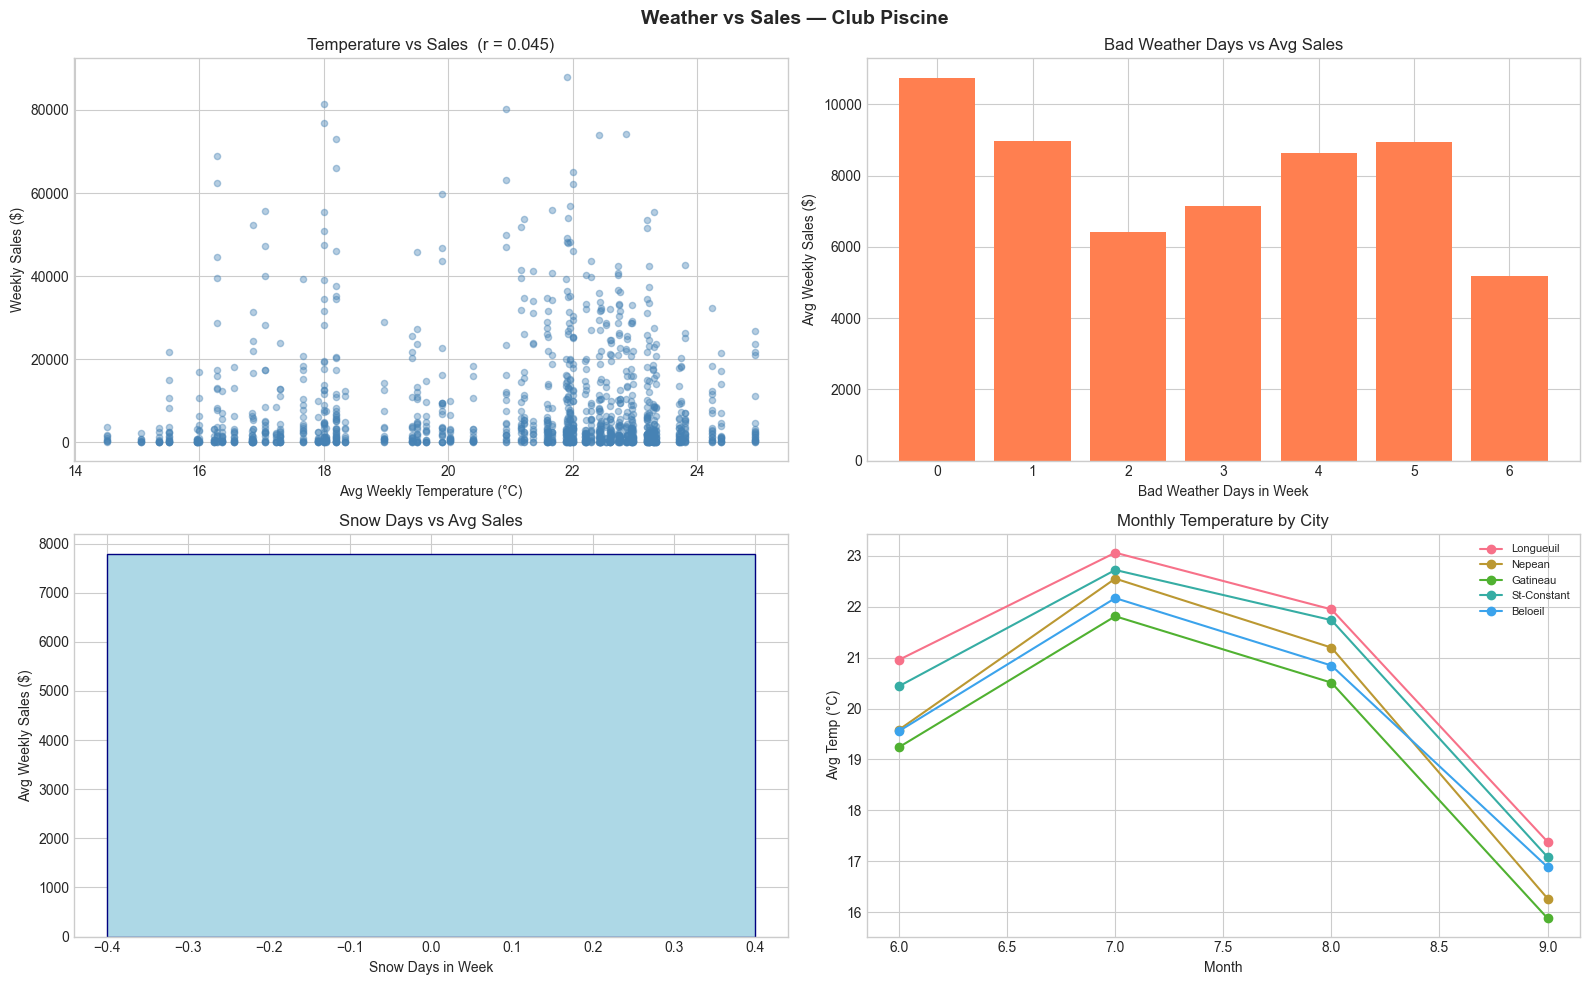

✅ Saved: weather_vs_sales.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax1 = axes[0, 0]
ax1.scatter(weekly_weather['avg_temp'], weekly_weather['sales'], alpha=0.4, color='steelblue', s=20)
corr = weekly_weather['avg_temp'].corr(weekly_weather['sales'])
ax1.set_xlabel('Avg Weekly Temperature (°C)')
ax1.set_ylabel('Weekly Sales ($)')
ax1.set_title(f'Temperature vs Sales  (r = {corr:.3f})')

ax2 = axes[0, 1]
bw = weekly_weather.groupby('bad_weather_days')['sales'].mean()
ax2.bar(bw.index, bw.values, color='coral')
ax2.set_xlabel('Bad Weather Days in Week')
ax2.set_ylabel('Avg Weekly Sales ($)')
ax2.set_title('Bad Weather Days vs Avg Sales')

ax3 = axes[1, 0]
sn = weekly_weather.groupby('snow_days')['sales'].mean()
ax3.bar(sn.index, sn.values, color='lightblue', edgecolor='navy')
ax3.set_xlabel('Snow Days in Week')
ax3.set_ylabel('Avg Weekly Sales ($)')
ax3.set_title('Snow Days vs Avg Sales')

ax4 = axes[1, 1]
for city in weekly_weather['city'].dropna().unique():
    d = weekly_weather[weekly_weather['city']==city].groupby('month')['avg_temp'].mean()
    ax4.plot(d.index, d.values, marker='o', label=city)
ax4.set_xlabel('Month')
ax4.set_ylabel('Avg Temp (°C)')
ax4.set_title('Monthly Temperature by City')
ax4.legend(fontsize=8)

plt.suptitle('Weather vs Sales — Club Piscine', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'weather_vs_sales.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: weather_vs_sales.png')

---
## Cell 10: Save Outputs
---

In [ ]:
weather_weekly.to_csv(DATA_PROCESSED / 'weather_by_city_week.csv', index=False)
weekly_weather.to_csv(DATA_PROCESSED / 'weekly_sales_weather.csv', index=False)
print(f'✅ Saved: weather_by_city_week.csv  ({weather_weekly.shape})')
print(f'✅ Saved: weekly_sales_weather.csv  ({weekly_weather.shape})')
print('Next → 03_feature_engineering.ipynb')

✅ Saved: weather_by_city_week.csv  ((95, 11))
✅ Saved: weekly_sales_weather.csv  ((1333, 19))
Next → 03_feature_engineering.ipynb
